In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier

# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, classification_report
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

from sklearn.model_selection import LearningCurveDisplay, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, make_scorer

from scipy import stats

import math
from sklearn.cluster import AgglomerativeClustering

import requests
import logging



# CSF EDITS
import anndata as ad
import scanpy as sc
import pandas as pd
import seaborn as sns

gpu = True
if gpu:
    #GPU Libraries
    import cudf
    import cupy as cp



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('bcell_analysis.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Log the start of the analysis
logger.info('Starting CD4 AUTO NO NAIVE PBMC solo 2 dataset analysis')    

2025-06-24 15:52:14,514 - __main__ - INFO - Starting CD4 AUTO NO NAIVE PBMC solo 2 dataset analysis


In [2]:
os.getcwd()
dataset_dir = "CD4_CSF_SAMU"

logger.info('Loading dataset...')
# Loading dataset 
dataset = sc.read_h5ad(os.path.join("..", "Dataset","MatriciAddestramento", dataset_dir+".h5ad"))

Store_dir = os.path.join(os.getcwd(), "Store", dataset_dir)

if not os.path.exists(Store_dir):
    os.makedirs(Store_dir)
logger.info('Store directory created...')

os.chdir(Store_dir)
logger.info('Chdir directory changed...')

2025-06-24 15:52:14,523 - __main__ - INFO - Loading dataset...
2025-06-24 15:52:25,577 - __main__ - INFO - Store directory created...
2025-06-24 15:52:25,579 - __main__ - INFO - Chdir directory changed...


In [3]:
print(dataset)

AnnData object with n_obs × n_vars = 25684 × 17820
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch', 'leiden'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'leiden', 'leiden_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
print(list(dataset.var_names))

['AP006222.2', 'FAM87B', 'LINC00115', 'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15', 'AGRN', 'RNF223', 'C1orf159', 'LINC01342', 'TTLL10-AS1', 'TTLL10', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6', 'UBE2J2', 'SCNN1D', 'ACAP3', 'PUSL1', 'CPTP', 'TAS1R3', 'DVL1', 'MXRA8', 'AURKAIP1', 'CCNL2', 'MRPL20', 'ANKRD65', 'VWA1', 'ATAD3C', 'ATAD3B', 'ATAD3A', 'TMEM240', 'SSU72', 'AL645728.1', 'MIB2', 'MMP23B', 'CDK11B', 'SLC35E2B', 'CDK11A', 'NADK', 'GNB1', 'CALML6', 'TMEM52', 'CFAP74', 'GABRD', 'PRKCZ', 'FAAP20', 'SKI', 'MORN1', 'RER1', 'PEX10', 'PLCH2', 'PANK4', 'TNFRSF14', 'MMEL1', 'TTC34', 'PRDM16', 'ARHGEF16', 'MEGF6', 'TPRG1L', 'WRAP73', 'TP73', 'SMIM1', 'LRRC47', 'CEP104', 'DFFB', 'C1orf174', 'LINC01134', 'LINC01346', 'AJAP1', 'NPHP4', 'KCNAB2', 'CHD5', 'RPL22', 'RNF207', 'ICMT', 'LINC00337', 'GPR153', 'ACOT7', 'HES2', 'ESPN', 'TNFRSF25', 'PLEKHG5', 'NOL9', 'TAS1R1', 'ZBTB48', 'KLHL21', 'PHF13', 'THAP3', 'DNAJC11', 'CAMTA1', 'VAMP3', 'PER3', 'UTS2', 'TNFRSF9', 'PAR

# PREPROCESSING CLUSTERING

In [5]:
current = dataset.copy()
if gpu: 
    logger.info('GPU is enabled...')
    data = current.X
    cudf_df = cudf.DataFrame(data.astype(cp.float32), columns=current.var_names)
    logger.info('Calculating correlation matrix...')
    dataCorr = cudf_df.corr()
    logger.info('Correlation matrix calculated...')
    joblib.dump(dataCorr, "dataCorr.pkl", compress=3)
    logger.info('Correlation matrix saved...')

    #CLEAN UP GPU
    del cudf_df
    cp.get_default_memory_pool().free_all_blocks()
else:
    logger.info('GPU is disabled...')
    data = current.X
    logger.info('Calculating correlation matrix...')
    dataCorr = pd.DataFrame(data, columns=current.var_names).corr()
    logger.info('Correlation matrix calculated...')
    joblib.dump(dataCorr, "dataCorr.pkl", compress=3)
    logger.info('Correlation matrix saved...')

2025-05-20 14:02:01,061 - __main__ - INFO - GPU is enabled...
2025-05-20 14:02:06,049 - __main__ - INFO - Calculating correlation matrix...
2025-05-20 14:02:22,461 - __main__ - INFO - Correlation matrix calculated...
2025-05-20 14:04:18,503 - __main__ - INFO - Correlation matrix saved...


In [6]:
logger.info('Loading correlation matrix...')
dataCorr = joblib.load( "dataCorr.pkl") 
logger.info('Correlation matrix loaded...')
dataCorr = dataCorr.to_pandas()
logger.info('Correlation matrix converted to pandas...')
clusters = []
# Get absolute correlation values once
abs_corr = np.abs(dataCorr)
logger.info('Absolute correlation matrix calculated...')
for gene_i in dataCorr.index:
    # Get all correlations >= 0.9 for this gene
    high_corr_mask = abs_corr.loc[gene_i] >= 0.9
    cluster = dataCorr.columns[high_corr_mask].tolist()
    
    if len(cluster) > 1:  # Only add if cluster has more than 1 gene
        clusters.append(cluster)
logger.info('Clusters calculated...')
logger.info(f'Width of clusters:  {len(clusters)}')
joblib.dump(clusters, "clusters.pkl")
logger.info('Clusters saved...')

2025-05-20 14:04:18,777 - __main__ - INFO - Loading correlation matrix...
2025-05-20 14:04:43,111 - __main__ - INFO - Correlation matrix loaded...
2025-05-20 14:05:02,037 - __main__ - INFO - Correlation matrix converted to pandas...
2025-05-20 14:05:02,374 - __main__ - INFO - Absolute correlation matrix calculated...
2025-05-20 14:05:12,164 - __main__ - INFO - Clusters calculated...
2025-05-20 14:05:12,166 - __main__ - INFO - Width of clusters:  953
2025-05-20 14:05:12,216 - __main__ - INFO - Clusters saved...


In [7]:
logger.info('Loading clusters...')
clusters = joblib.load( "clusters.pkl")
logger.info('Clusters loaded...')
gene_list = list(dataset.var_names)
logger.info(f'Length of gene list:  {len(gene_list)}')

for cluster in clusters:
    for gene in cluster:
        if gene in gene_list:
            gene_list.remove(gene)
logger.info('Genes removed from gene list...')
logger.info(f'Length of gene list: {len(gene_list)}')

2025-05-20 14:05:12,223 - __main__ - INFO - Loading clusters...
2025-05-20 14:05:12,250 - __main__ - INFO - Clusters loaded...
2025-05-20 14:05:12,253 - __main__ - INFO - Length of gene list:  17820
2025-05-20 14:05:18,705 - __main__ - INFO - Genes removed from gene list...
2025-05-20 14:05:18,706 - __main__ - INFO - Length of gene list: 16867


In [8]:
current = dataset.copy()
data = pd.DataFrame(current.X, columns=current.var_names)
representative = {}
logger.info('Calculating variances...')
# Calculate variances once for all variables
all_variances = {var: data[var].var() for var in data.columns}
logger.info('Variances calculated...')
# Sort all variables by variance (highest to lowest) once
sorted_vars = sorted(all_variances.items(), key=lambda item: item[1], reverse=True)
sorted_vars_list = [var for var, _ in sorted_vars]
logger.info('Variances sorted...')
# Process clusters by size (largest first)
logger.info('Processing clusters...')
for cluster in sorted(clusters, key=len, reverse=True):
    cluster_tuple = tuple(cluster)
    
    # Find the highest variance variable in this cluster that isn't already used
    found_representative = False
    for var in sorted_vars_list:
        if var in cluster and var not in representative.values():
            representative[cluster_tuple] = var
            found_representative = True
            break
    
    # If we couldn't find an unused representative, use the highest variance one anyway
    if not found_representative:
        for var in sorted_vars_list:
            if var in cluster:
                representative[cluster_tuple] = var
                break
logger.info('Representative calculated...')
# Filter out subsets more efficiently
unique_clusters = {}
cluster_tuples = list(representative.keys())
logger.info('Cluster tuples sorted...') 
# Sort by length once
cluster_tuples.sort(key=len)
logger.info('Cluster tuples sorted...')     
# Use a more efficient algorithm to filter subsets
logger.info('Filtering subsets...')
for i, cluster in enumerate(cluster_tuples):
    is_unique = True
    cluster_set = set(cluster)
    
    # Only check against larger clusters
    for j in range(i+1, len(cluster_tuples)):
        larger_cluster = cluster_tuples[j]
        if cluster_set.issubset(set(larger_cluster)):
            is_unique = False
            break
    
    if is_unique:
        unique_clusters[cluster] = representative[cluster]
logger.info('Unique clusters calculated...')
joblib.dump(unique_clusters, "uniqueClusters.pkl")
logger.info('Unique clusters saved...')

2025-05-20 14:05:18,987 - __main__ - INFO - Calculating variances...
2025-05-20 14:05:33,192 - __main__ - INFO - Variances calculated...
2025-05-20 14:05:33,208 - __main__ - INFO - Variances sorted...
2025-05-20 14:05:33,209 - __main__ - INFO - Processing clusters...
2025-05-20 14:05:35,735 - __main__ - INFO - Representative calculated...
2025-05-20 14:05:35,736 - __main__ - INFO - Cluster tuples sorted...
2025-05-20 14:05:35,737 - __main__ - INFO - Cluster tuples sorted...
2025-05-20 14:05:35,738 - __main__ - INFO - Filtering subsets...
2025-05-20 14:05:36,066 - __main__ - INFO - Unique clusters calculated...
2025-05-20 14:05:36,083 - __main__ - INFO - Unique clusters saved...


In [10]:

def find_key_by_value_in_tuple(
    unique_clusters_path, target_value: str
) -> tuple | None:
    """
    Loads a dictionary of unique clusters from a file and searches for a key
    (cluster tuple) that has the specified target value as its value.

    Args:
        unique_clusters_path (str): The path to the file containing the
            unique clusters dictionary (created using joblib.dump).
        target_value (str): The value to search for among the values in the
            dictionary.

    Returns:
        tuple | None: The key (cluster tuple) that has the target value as its
            value. Returns None if the target value is not found.
    """

    for cluster_tuple, value in unique_clusters.items():
        if value == target_value:
            return cluster_tuple

    return None
print(find_key_by_value_in_tuple(unique_clusters, "HLA-DRB1"))
print("HLA-DRB1" in gene_list)

None
False


In [11]:
gene_list.extend(gene for gene in unique_clusters.values() if gene not in gene_list) 
logger.info(f'Length of gene list: {len(gene_list)}')
logger.info(f'Adding back HLA-DRB1 cluster...')
cluster = ['HLA-DRA', 'HLA-DRB1', 'HLA-DQB1', 'HLA-DMA', 'HLA-DPA1', 'HLA-DPB1']
if gene not in gene_list:
        gene_list.append(gene)  # Append each gene individually

2025-05-20 14:06:03,963 - __main__ - INFO - Length of gene list: 17236
2025-05-20 14:06:03,964 - __main__ - INFO - Adding back HLA-DRB1 cluster...


In [12]:
logger.info('Declustering dataset...')
datasetDeclustered = dataset[:, gene_list]
logger.info('Dataset declustered...')
datasetDeclustered.write_h5ad("datasetDeclustered.h5ad")#Dataset che viene utilizzato per tutte le analisi successive
logger.info('Dataset declustered saved...')
print(datasetDeclustered)

2025-05-20 14:06:07,419 - __main__ - INFO - Declustering dataset...
2025-05-20 14:06:07,443 - __main__ - INFO - Dataset declustered...
2025-05-20 14:06:14,147 - __main__ - INFO - Dataset declustered saved...


View of AnnData object with n_obs × n_vars = 25684 × 17236
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch', 'leiden'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'leiden', 'leiden_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


# DIVISIONE TRAIN VALIDATION E TEST DEL DATASET

In [7]:
from pprint import pprint
import math
sample_len = len(dataset.obs['sample'].unique().tolist())

# proportion for test and validation
# 80 20 20 
logger.info('Proportion for test and validation...')
logger.info('Length of sample list: ' + str(math.floor(sample_len)))
logger.info('Training sample needed: ' + str(math.floor(sample_len * 0.6)))
logger.info('Validation sample needed: ' + str(math.floor(sample_len * 0.2)))
logger.info('Test sample needed: ' + str(math.floor(sample_len * 0.2)))

2025-06-24 15:53:10,316 - __main__ - INFO - Proportion for test and validation...
2025-06-24 15:53:10,317 - __main__ - INFO - Length of sample list: 15
2025-06-24 15:53:10,318 - __main__ - INFO - Training sample needed: 9
2025-06-24 15:53:10,319 - __main__ - INFO - Validation sample needed: 3
2025-06-24 15:53:10,320 - __main__ - INFO - Test sample needed: 3


In [8]:
import numpy as np
import pandas as pd
import math
import anndata as ad  # Import AnnData
import pandas as pd
from skopt import BayesSearchCV
from sklearn.model_selection import PredefinedSplit

from imblearn.under_sampling import RandomUnderSampler

# --- Configuration ---
dataset = ad.read_h5ad("CD4TNONAIVE_csf_datasetDeclustered.h5ad")
rng_seed = 53  # <--- CHANGE THIS SEED TO GET DIFFERENT SPLITS
# train_proportion = 0.6
# validation_proportion = 0.2
# test_proportion = 0.2
# --- End Configuration ---


def create_splits_from_sample_ids(
    dataset, train_sample_ids, validation_sample_ids, test_sample_ids, rng_seed
):
    """
    Creates train, validation, and test AnnData subsets based on provided sample IDs.

    Args:
        dataset (AnnData): The original AnnData object.
        train_sample_ids (list): List of sample IDs for the training set.
        validation_sample_ids (list): List of sample IDs for the validation set.
        test_sample_ids (list): List of sample IDs for the test set.
        rng_seed (int): Random seed for shuffling.

    Returns:
        tuple: A tuple containing the train, validation, and test AnnData subsets.
    """

    # 4. Create boolean masks for each set
    train_mask = dataset.obs["sample"].isin(train_sample_ids)
    validation_mask = dataset.obs["sample"].isin(validation_sample_ids)
    test_mask = dataset.obs["sample"].isin(test_sample_ids)

    # 5. Create AnnData subsets
    train_adata = dataset[train_mask].copy()
    validation_adata = dataset[validation_mask].copy()
    test_adata = dataset[test_mask].copy()

    # 6. Shuffle the observations within each AnnData dataset (maintaining
    # reproducibility)
    # Using the same rng_seed for this shuffling step for consistency,
    # or you can use a different one if desired.
    if train_adata.shape[0] > 0:
        train_adata = train_adata[
            np.random.RandomState(rng_seed).permutation(train_adata.shape[0])
        ]
    if validation_adata.shape[0] > 0:
        validation_adata = validation_adata[
            np.random.RandomState(rng_seed).permutation(validation_adata.shape[0])
        ]
    if test_adata.shape[0] > 0:
        test_adata = test_adata[
            np.random.RandomState(rng_seed).permutation(test_adata.shape[0])
        ]

    return train_adata, validation_adata, test_adata


train_sample_ids = ["19270", "49131", "58637","74594", "YYW_CSF","KJS_CSF","41540","45044","83775"]
validation_sample_ids = ["71658", "JYJ_CSF","85037","95809"]
test_sample_ids = ["60249", "32190"]



train_adata, validation_adata, test_adata = create_splits_from_sample_ids(
    dataset, train_sample_ids, validation_sample_ids, test_sample_ids, rng_seed
)


# 7. Print dataset statistics
print("\n--- Training Set ---")
print(f"Shape: {train_adata.shape}")
if train_adata.shape[0] > 0:
    print(f"Unique samples: {len(train_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(train_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(train_adata.obs['condition'] == 'CTRL')}")
else:
    print("Training set is empty.")

print("\n--- Validation Set ---")
print(f"Shape: {validation_adata.shape}")
if validation_adata.shape[0] > 0:
    print(f"Unique samples: {len(validation_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(validation_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(validation_adata.obs['condition'] == 'CTRL')}")
else:
    print("Validation set is empty.")

print("\n--- Test Set ---")
print(f"Shape: {test_adata.shape}")
if test_adata.shape[0] > 0:
    print(f"Unique samples: {len(test_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(test_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(test_adata.obs['condition'] == 'CTRL')}")
else:
    print("Test set is empty.")


# 8. Extract features (X) and target (y) for each set
def extract_xy(adata, condition_label="MS"):
    if adata.shape[0] == 0:
        # Return empty DataFrame/Series with expected dtypes if set is empty
        return pd.DataFrame(
            columns=dataset.var_names
        ), pd.Series(
            dtype="int"
        )  # Use dataset.var_names to ensure correct columns

    y = (adata.obs["condition"] == condition_label).astype(int)
    # Handle sparse matrices for X
    if hasattr(adata.X, "toarray"):  # Checks if it's a sparse matrix
        x_data = adata.X.toarray()
    else:
        x_data = adata.X
    x = pd.DataFrame(x_data, columns=adata.var_names, index=adata.obs_names)
    return x, y


x_train, y_train = extract_xy(train_adata)
x_val, y_val = extract_xy(validation_adata)
x_test, y_test = extract_xy(test_adata)

print("\nExtracted X/y for train, validation, and test sets.")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


# Sanity check: ensure no sample ID overlap between sets
train_samples_set = set(train_sample_ids)
val_samples_set = set(validation_sample_ids)
test_samples_set = set(test_sample_ids)

if not train_samples_set.isdisjoint(val_samples_set):
    print(
        f"ERROR: Overlap between TRAIN and VALIDATION samples: {train_samples_set.intersection(val_samples_set)}"
    )
if not train_samples_set.isdisjoint(test_samples_set):
    print(
        f"ERROR: Overlap between TRAIN and TEST samples: {train_samples_set.intersection(test_samples_set)}"
    )
if not val_samples_set.isdisjoint(test_samples_set):
    print(
        f"ERROR: Overlap between VALIDATION and TEST samples: {val_samples_set.intersection(test_samples_set)}"
    )

print("\nSplit complete.")



--- Training Set ---
Shape: (16463, 17236)
Unique samples: 9
MS samples: 11200
CTRL samples: 5263

--- Validation Set ---
Shape: (4629, 17236)
Unique samples: 4
MS samples: 3523
CTRL samples: 1106

--- Test Set ---
Shape: (4592, 17236)
Unique samples: 2
MS samples: 3129
CTRL samples: 1463

Extracted X/y for train, validation, and test sets.
x_train shape: (16463, 17236), y_train shape: (16463,)
x_val shape: (4629, 17236), y_val shape: (4629,)
x_test shape: (4592, 17236), y_test shape: (4592,)

Split complete.


In [9]:
from imblearn.under_sampling import RandomUnderSampler

# Apply RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=5263/8000, random_state=42) 

x_resampled, y_resampled = rus.fit_resample(x_train, y_train)

print("Shape of x_train_resampled:", x_resampled.shape)
print("Shape of y_train_resampled:", y_resampled.shape)


Shape of x_train_resampled: (13263, 17236)
Shape of y_train_resampled: (13263,)


In [10]:
import pandas as pd
from skopt import BayesSearchCV
from sklearn.model_selection import PredefinedSplit


def bayesianOpt(
    pipeline,
    hyperparameters,
    iteration,
    scorer,
    njobs,
    x_train,
    y_train,
    x_val,
    y_val,
):
    """
    Performs Bayesian optimization using a predefined validation set.

    Args:
        pipeline: The scikit-learn pipeline to optimize.
        hyperparameters: The hyperparameter search space for BayesSearchCV.
        iteration: The number of optimization iterations.
        scorer: The scoring metric to use.
        njobs: The number of parallel jobs to run.
        x_train: The training data features.
        y_train: The training data labels.
        x_val: The validation data features.
        y_val: The validation data labels.

    Returns:
        The BayesSearchCV result object.
    """

    # Create a predefined split using x_train and x_val
    test_fold = [-1] * len(x_train) + [0] * len(x_val)
    X = pd.concat([x_train, x_val], axis=0)
    y = pd.concat([y_train, y_val], axis=0)
    predefined_split = PredefinedSplit(test_fold)

    bayesianSearchResult = BayesSearchCV(
        estimator=pipeline,
        search_spaces=hyperparameters,
        cv=predefined_split,
        n_iter=iteration,
        return_train_score=True,
        refit="f1",
        scoring=scorer,
        n_jobs=njobs,
        verbose=3,
    )
    bayesianSearchResult.fit(X, y)
    print("Iperparametri:", bayesianSearchResult.best_params_)
    return bayesianSearchResult


In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline


def plot_confusion_matrix(
    cm, classes, normalize=False, title="Confusion matrix", cmap=plt.cm.Blues
):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    Dynamically adjusts text color for readability.
    """
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        # Dynamically determine text color
        color = "white" if cm[i, j] < thresh else "black"  # Invert condition

        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color=color,
        )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()


def prettyPrint(model, name, x_train, y_train, val=False, test=False):
    print(name + ":")
    print("Iperparametri: ", model[-1].get_params())
    print("\nTrain F1 score: ", f1_score(y_train, model.predict(x_train), average='macro'))
    print(classification_report(y_train, model.predict(x_train)), "\n\n")
    if val:
        print("\nVal F1 score: ", f1_score(y_val, model.predict(x_val), average='macro'))
        print(classification_report(y_val, model.predict(x_val)), "\n\n")
    
    if test:  
        print("\nTest F1 score: ", f1_score(y_test, model.predict(x_test), average='macro'))
        print(classification_report(y_test, model.predict(x_test)), "\n\n")

# Example Usage (replace with your actual data)
# Assuming you have x_train, y_train, x_test, y_test, x_val, y_val loaded
# MODEL TEST
# model = joblib.load("bayesianOptResult.pkl")
# prettyPrint(model, "CD4 PBMC", x_train, y_train, x_test, y_test, x_val, y_val, True)


In [12]:
pipeline = Pipeline(steps=[('scaling', MinMaxScaler()), ('classifier', XGBClassifier(random_state=42, device="cuda"))])

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

scorer = {
    'Accuracy': 'accuracy',
    'precision 0': make_scorer(precision_class_0),
    'precision 1': make_scorer(precision_class_1),
    'recall 0': make_scorer(recall_class_0),
    'recall 1': make_scorer(recall_class_1),
    'f1': make_scorer(f1_score, average='macro')
}

In [ ]:
param_dist = {
    'classifier__n_estimators': Integer(50, 600),  # Numero di alberi
    'classifier__max_depth': Integer(2, 15),  # Profondità dell'albero
    'classifier__learning_rate': Real(0.001, 0.7, prior='log-uniform'),  # Tasso di apprendimento
    'classifier__gamma': Real(0.0001, 1, prior='log-uniform'),  # Minimum loss reduction
    'classifier__min_child_weight': Integer(1, 8), 
    'classifier__scale_pos_weight': Categorical([5263/8000]),
    'classifier__reg_alpha': Real(0.001, 100, prior='log-uniform'),  # Regolarizzazione L1
    'classifier__reg_lambda': Real(0.001, 100, prior='log-uniform'),  # Regolarizzazione L2}
}

bayesianOptResult = bayesianOpt(pipeline, param_dist, 400, scorer, 1, x_train, y_train, x_val, y_val)
joblib.dump(bayesianOptResult, "bayesianOptResult.pkl")

Fitting 1 folds for each of 1 candidates, totalling 1 fits


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0xfc9f4ce164a0>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 589, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument
KeyboardInterrupt: 


CD4 PBMC:
Iperparametri:  {'cv': PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])), 'error_score': 'raise', 'estimator__memory': None, 'estimator__steps': [('scaling', MinMaxScaler()), ('classifier', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...))], 'estimator__verbose': False, 'est

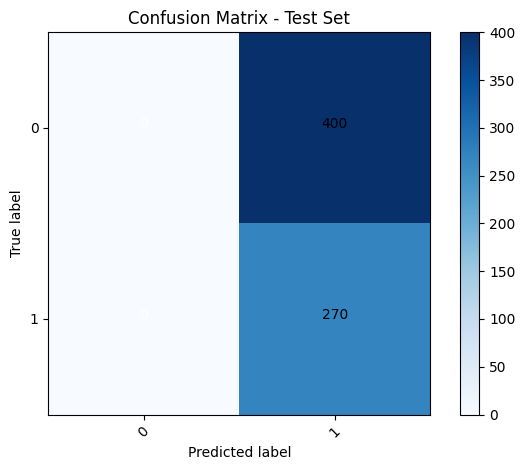

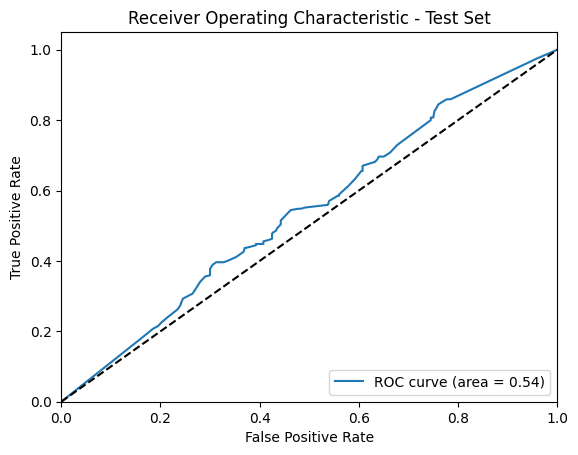

ROC AUC score: 0.54

Test f1 score:  0.2872340425531915
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       400
           1       0.40      1.00      0.57       270

    accuracy                           0.40       670
   macro avg       0.20      0.50      0.29       670
weighted avg       0.16      0.40      0.23       670
 




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# MODEL TEST
model = joblib.load("bayesianOptResult.pkl")
prettyPrint(model, "CD4 PBMC", x_resampled, y_resampled, x_test, y_test, x_val, y_val, True)

In [23]:
# Refittiamo il modello su tutto il dataset
model = joblib.load("bayesianOptResult.pkl")
print("Best Parameters: \n{}\n".format(model.best_params_))

Best Parameters: 
OrderedDict([('classifier__gamma', 0.0001), ('classifier__learning_rate', 0.044980648663355424), ('classifier__max_depth', 15), ('classifier__min_child_weight', 8), ('classifier__n_estimators', 600), ('classifier__reg_alpha', 0.001), ('classifier__reg_lambda', 0.001), ('classifier__scale_pos_weight', 0.657875)])



Fitted pipeline on the resampled training data.

--- Evaluation Metrics on Validation Set ---
Accuracy: 0.7176
Precision: 0.8168
Recall: 0.8110
F1-Score: 0.8138
ROC AUC: 0.6157

Confusion Matrix:
[[ 465  641]
 [ 666 2857]]


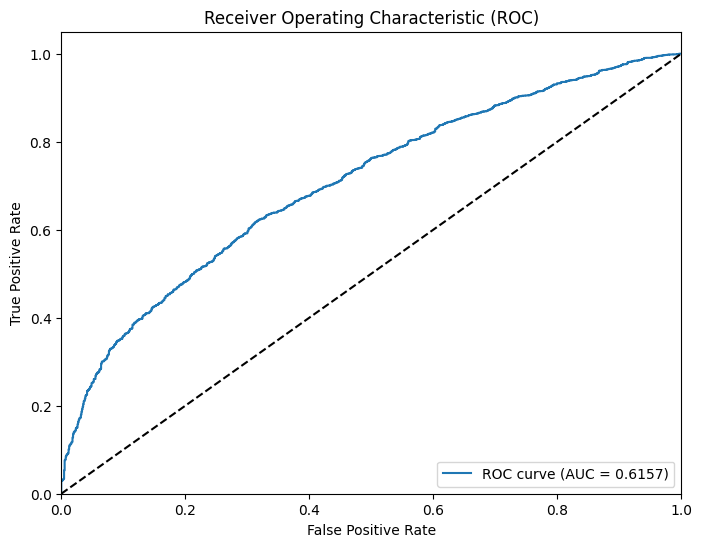

In [13]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,  # Import roc_curve
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt  # Import matplotlib

# Define the best parameters found by BayesSearchCV
best_params = {
    'n_estimators': 600,
    'max_depth': 9,
    'learning_rate': 0.1659888170735268,
    'gamma': 0.0001,
    'min_child_weight': 1,
    'scale_pos_weight': 0.657875,
    'reg_alpha': 0.008902455194353705,
    'reg_lambda': 0.001,
}
# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(device="cuda",**best_params  # Pass best_params directly
)

# Create a pipeline with MinMaxScaler and XGBoost
pipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),  # MinMaxScaler
        ("classifier", xgb_classifier),  # XGBoost classifier
    ]
)

# Fit the pipeline on the resampled training data
pipeline.fit(x_train, y_train)

print("Fitted pipeline on the resampled training data.")

# Make predictions on the validation set
y_pred_val = pipeline.predict(x_val)

# Evaluate predictions on the validation set
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)
roc_auc = roc_auc_score(y_val, pipeline.predict_proba(x_val)[:, 1])
confusion = confusion_matrix(y_val, y_pred_val)

print("\n--- Evaluation Metrics on Validation Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion)

# --- ROC Curve ---
y_pred_proba = pipeline.predict_proba(x_val)[:, 1]  # Probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()


Fitted pipeline on the combined training and validation data.

--- Evaluation Metrics on Test Set ---
Accuracy: 0.7156
Precision: 0.7456
Recall: 0.8843
F1-Score: 0.8091
ROC AUC: 0.6195

Confusion Matrix:
[[ 519  944]
 [ 362 2767]]


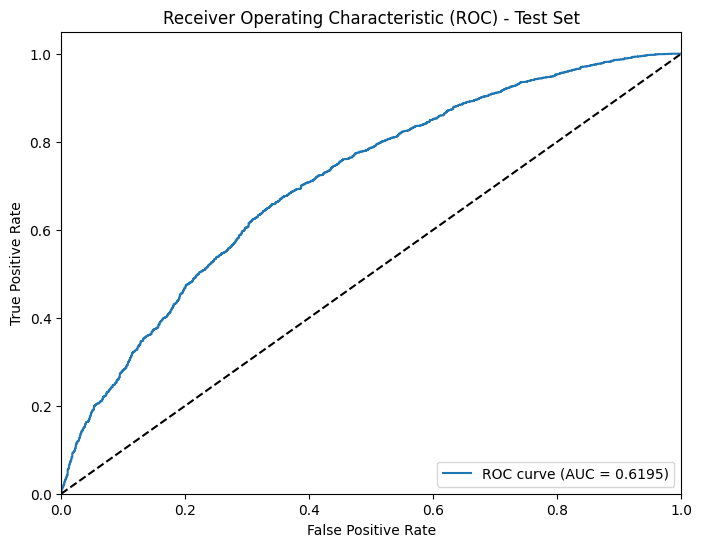

In [43]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,  # Import roc_curve
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt  # Import matplotlib
import pandas as pd

# Define the best parameters found by BayesSearchCV
best_params = {
    'n_estimators': 600,
    'max_depth': 9,
    'learning_rate': 0.1659888170735268,
    'gamma': 0.0001,
    'min_child_weight': 1,
    'scale_pos_weight': 0.657875,
    'reg_alpha': 0.008902455194353705,
    'reg_lambda': 0.001,
}

# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(
    device="cuda", **best_params  # Pass best_params directly
)

pipeline = model.best_estimator_

# Combine the training and validation data
X_full = pd.concat([x_train, x_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

# Fit the pipeline on the full dataset
pipeline.fit(X_full, y_full)

print("Fitted pipeline on the combined training and validation data.")

# Make predictions on the test set
y_pred_test = pipeline.predict(x_test)

# Evaluate predictions on the test set
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, pipeline.predict_proba(x_test)[:, 1])
confusion = confusion_matrix(y_test, y_pred_test)

print("\n--- Evaluation Metrics on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion)


# --- ROC Curve ---
y_pred_proba_test = (
    pipeline.predict_proba(x_test)[:, 1]
)  # Probabilities for the positive class
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_test, tpr_test, label=f"ROC curve (AUC = {roc_auc:.4f})"
)  # Use fpr_test, tpr_test
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) - Test Set")  # Correct Title
plt.legend(loc="lower right")
plt.show()


In [11]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Define the best parameters found by BayesSearchCV
best_params = {'objective': 'binary:logistic',
               'colsample_bylevel': None,
               'colsample_bynode': None,
               'colsample_bytree': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 0.0001, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1659888170735268, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 9, 'max_leaves': None, 'min_child_weight': 1, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 600, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.008902455194353705, 'reg_lambda': 0.001, 'sampling_method': None, 'scale_pos_weight': 0.657875, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}



# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(
    device="cuda",
    **best_params  # Pass best_params directly
)

# Create a pipeline with MinMaxScaler and XGBoost
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # MinMaxScaler
    ('classifier', xgb_classifier)  # XGBoost classifier
])

# Combine the training and validation data
X_full = pd.concat([x_resampled, x_val, x_test], axis=0)
y_full = pd.concat([y_resampled, y_val, y_test], axis=0)

# Fit the pipeline on the full dataset
pipeline.fit(X_full, y_full)

print("Fitted pipeline on the combined training, validation data and test data.")

#inutile fare predizioni qui

#salviamo
joblib.dump(pipeline, "BestModelRefittedWholeDataset.pkl")


Fitted pipeline on the combined training, validation data and test data.


['BestModelRefittedWholeDataset.pkl']

In [30]:
model2_disp = RocCurveDisplay.from_estimator(pipeline[-1], x_val, y_val, name="Gradient Boosting", ax=axes[1])

NameError: name 'RocCurveDisplay' is not defined

# SAMUELE


In [5]:
dataset = ad.read_h5ad("CD4TNONAIVE_csf_datasetDeclustered.h5ad")
current = pd.DataFrame(dataset.X, columns= dataset.var_names)
current.insert(0, "SampleID", dataset.obs['sample'].values)
current.insert(1, "Label", dataset.obs['condition'].values)

train_ids = [
    '19270', '49131', '58637', '74594', 'YYW_CSF', 'KJS_CSF', # MS
    '41540', '45044', '83775'  # CTRL
]
val_ids = [
    '71658', 'JYJ_CSF',  # MS
    '85037', '95809'   # CTRL
]

test_ids = list(set(current['SampleID'].unique()) - set(train_ids) - set(val_ids))

print(set.intersection(set(val_ids), set(train_ids)))

print(train_ids, val_ids, test_ids)

train = current[current['SampleID'].isin(train_ids)].sample(frac=1, random_state=42)
val = current[current['SampleID'].isin(val_ids)].sample(frac=1, random_state=42)
test = current[current['SampleID'].isin(test_ids)].sample(frac=1, random_state=42)

def printData(msg, data, label):
    print(f"\n{msg}")
    print(data.shape)
    print("I malati sono: ", sum(label == True))
    print("I sani sono: ", sum(label == False))

y_train = train['Label'] == "MS"
x_train = train.drop(columns=['SampleID', 'Label'])
x_train.insert(0, "Indeces", x_train.index)
printData("Dataset di train:", x_train, y_train)

# x_train, y_train = TomekLinks(sampling_strategy='majority', n_jobs=-1).fit_resample(x_train, y_train)
# printData("Dataset di train after Tomek:", x_train, y_train)

x_train, y_train = RandomUnderSampler(sampling_strategy=5263/8000, random_state=42).fit_resample(x_train, y_train)
printData("Dataset di train after RandomUnderSampling:", x_train, y_train)

# x_train, y_train = RepeatedEditedNearestNeighbours(sampling_strategy='majority', n_neighbors=5, max_iter=200, n_jobs=-1).fit_resample(x_train, y_train)
# printData("Dataset di train after ENN:", x_train, y_train)

x_train.index = x_train['Indeces']

y_val = val['Label'] == "MS"
x_val = val.drop(columns=['SampleID', 'Label'])
printData("Dataset di Validation:", x_val, y_val)

y_test = test['Label'] == "MS"
x_test = test.drop(columns=['SampleID', 'Label'])
printData("Dataset di Test:", x_test, y_test)

split_index = [-1 if x in x_train.index else 0 for x in pd.concat([x_train, x_val]).index]

x_train.drop(columns=['Indeces'], inplace=True)

pds = PredefinedSplit(test_fold = split_index)

sampleSum = dataset.X.shape[0]

print()
print(len(y_train)*100/sampleSum, len(y_val)*100/sampleSum, len(y_test)*100/sampleSum)

set()
['19270', '49131', '58637', '74594', 'YYW_CSF', 'KJS_CSF', '41540', '45044', '83775'] ['71658', 'JYJ_CSF', '85037', '95809'] ['32190', '60249']

Dataset di train:
(16463, 17237)
I malati sono:  11200
I sani sono:  5263


NameError: name 'RandomUnderSampler' is not defined

In [6]:
def prettyPrint(model, name, x_train, y_train, val=False, test=False):
    print(name + ":")
    print("Iperparametri: ", model[-1].get_params())
    print("\nTrain F1 score: ", f1_score(y_train, model.predict(x_train), average='macro'))
    print(classification_report(y_train, model.predict(x_train)), "\n\n")
    if val:
        print("\nVal F1 score: ", f1_score(y_val, model.predict(x_val), average='macro'))
        print(classification_report(y_val, model.predict(x_val)), "\n\n")
    
    if test:  
        print("\nTest F1 score: ", f1_score(y_test, model.predict(x_test), average='macro'))
        print(classification_report(y_test, model.predict(x_test)), "\n\n")

pipeline = Pipeline(steps=[
    ('scaling', MinMaxScaler()),
    ('classifier', XGBClassifier(random_state=42))])

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

def weighted_f1(y_true, y_pred, weight_0=0.7, weight_1=0.3):
    f1_0 = f1_score(y_true, y_pred, pos_label=0)
    f1_1 = f1_score(y_true, y_pred, pos_label=1)
    return weight_0 * f1_0 + weight_1 * f1_1

scorer = {
    'Accuracy': 'accuracy',
    'precision 0': make_scorer(precision_class_0),
    'precision 1': make_scorer(precision_class_1),
    'recall 0': make_scorer(recall_class_0),
    'recall 1': make_scorer(recall_class_1),
    'f1': make_scorer(f1_score, average='macro')
}

# 'f1_ManualWeighted': make_scorer(weighted_f1, weight_0=0.7, weight_1=0.3)

param_dist = {
    'classifier__n_estimators': Integer(50, 600),  # Numero di alberi
    'classifier__max_depth': Integer(2, 15),  # Profondità dell'albero
    'classifier__learning_rate': Real(0.001, 0.7, prior='log-uniform'),  # Tasso di apprendimento
    'classifier__gamma': Real(0.0001, 1, prior='log-uniform'),  # Minimum loss reduction
    'classifier__min_child_weight': Integer(1, 8), 
    'classifier__scale_pos_weight': Categorical([5263/8000]),
    'classifier__reg_alpha': Real(0.001, 100, prior='log-uniform'),  # Regolarizzazione L1
    'classifier__reg_lambda': Real(0.001, 100, prior='log-uniform'),  # Regolarizzazione L2
}

In [41]:
best_params = {
    'classifier__n_estimators': 600,
    'classifier__max_depth': 9,
    'classifier__learning_rate': 0.1659888170735268,
    'classifier__gamma': 0.0001,
    'classifier__min_child_weight': 1,
    'classifier__scale_pos_weight': 0.657875,
    'classifier__reg_alpha': 0.008902455194353705,
    'classifier__reg_lambda': 0.001,
}

pipeline = model.best_estimator_

pipeline.fit(x_train, y_train)
prettyPrint(pipeline, "cd4 csf samuele", x_train, y_train, True, True)

cd4 csf samuele:
Iperparametri:  {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 0.0001, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1659888170735268, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 9, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 600, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.008902455194353705, 'reg_lambda': 0.001, 'sampling_method': None, 'scale_pos_weight': 0.657875, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

Train F1 score:  1.0
              pre

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.35      0.44      1463
           1       0.74      0.88      0.81      3129

    accuracy                           0.71      4592
   macro avg       0.66      0.62      0.62      4592
weighted avg       0.69      0.71      0.69      4592



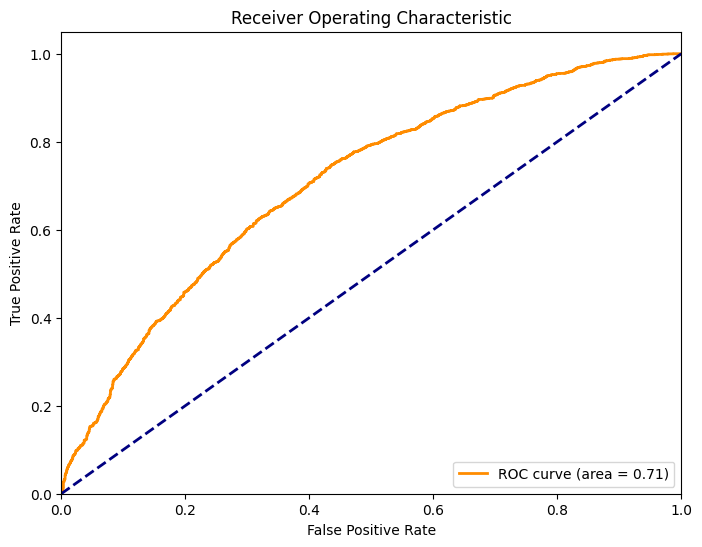

In [16]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report

# Load the model
model = joblib.load("model2_extVal_CSF_CD4.pkl")
y_pred = model.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Get predicted probabilities
y_pred_proba = model.predict_proba(x_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc
)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()


Pipeline(steps=[('scaling', MinMaxScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=0.0001,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.1659888170735268, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=9,
                               max_leaves=None, min_child_weight=1, missing=nan,
                               monotone_constraints=None, multi_st